# Data visualization
This notebook explores the input data. It uses scripts available in the Git of the [competition](https://github.com/royerlab/kaggle-cell-tracking-competition/tree/main)

# Defining input data

In [1]:
from pathlib import Path
import os
data_path = Path('/kaggle/input/competitions/biohub-cell-tracking-during-development')
training_path =  data_path/'train'
test_path = data_path/'test'

#------------ Listing folders in train -----------
print("Input contents:", os.listdir(training_path)[:5],"\n")
print(" First 5 elements in train folder, it contains '.geff' folders (annotated graphs) and '.zarr' folder (videos)")

Input contents: ['6bba_2540cd90.geff', '44b6_0b24845f.geff', '44b6_996155de.geff', '44b6_0c582fdc.geff', '6bba_cf35214c.zarr'] 

 First 5 elements in train folder, it contains '.geff' folders (annotated graphs) and '.zarr' folder (videos)


# Configuration

In [2]:
COMP_DIR = data_path
TEST_DIR = test_path
TRAIN_DIR = training_path

ARTIFACTS = "/kaggle/input/datasets/thibautgoldsborough/cellmot-baseline-artifacts/cellmot-baseline-artifacts"

REPO_DIR = "/kaggle/working/repo"
METHOD = "unet_transformer"

# Git clone


In [3]:
!git clone https://github.com/royerlab/kaggle-cell-tracking-competition.git

Cloning into 'kaggle-cell-tracking-competition'...
remote: Enumerating objects: 119, done.
remote: Counting objects: 100% (119/119), done.
remote: Compressing objects: 100% (71/71), done.
remote: Total 119 (delta 59), reused 103 (delta 44), pack-reused 0 (from 0)
Receiving objects: 100% (119/119), 5.11 MiB | 35.15 MiB/s, done.
Resolving deltas: 100% (59/59), done.


In [4]:
!ls kaggle-cell-tracking-competition



assets	 metrics.md	 README.md  src    visualize
LICENSE  pyproject.toml  scripts    tests


# Offline install & setup

In [6]:
GIT_DIR = "/kaggle/working/kaggle-cell-tracking-competition"

In [12]:
import os
print("GIT_DIR:", GIT_DIR)
for root, dirs, files in os.walk(GIT_DIR):
    if "visualize_ground_truth.py" in files:
        print("Found at:", root)

GIT_DIR: /kaggle/working/kaggle-cell-tracking-competition
Found at: /kaggle/working/kaggle-cell-tracking-competition/visualize


# Visualize data

In [13]:
!pip install -q tracksdata

In [18]:
!rm -rf /kaggle/working/napari-env
!python -m venv /kaggle/working/napari-env --without-pip
!curl -sS https://bootstrap.pypa.io/get-pip.py -o /kaggle/working/get-pip.py
!/kaggle/working/napari-env/bin/python /kaggle/working/get-pip.py
!/kaggle/working/napari-env/bin/pip --version

Error in sitecustomize; set PYTHONVERBOSE for traceback:
ModuleNotFoundError: No module named 'wrapt'
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 16.6 MB/s  0:00:00
Error in sitecustomize; set PYTHONVERBOSE for traceback:
ModuleNotFoundError: No module named 'wrapt'
pip 26.1.2 from /kaggle/working/napari-env/lib/python3.12/site-packages/pip (python 3.12)


In [19]:
!/kaggle/working/napari-env/bin/pip install -q matplotlib tracksdata torch

Error in sitecustomize; set PYTHONVERBOSE for traceback:
ModuleNotFoundError: No module named 'wrapt'


In [20]:
result = subprocess.run(
    ["/kaggle/working/napari-env/bin/python", "-c",
     "import numpy, torch, tracksdata, matplotlib; print('OK', numpy.__version__, torch.__version__, tracksdata.__version__)"],
    capture_output=True, text=True
)
print(result.stdout)
print(result.stderr)


Error in sitecustomize; set PYTHONVERBOSE for traceback:
ModuleNotFoundError: No module named 'wrapt'
Traceback (most recent call last):
  File "<string>", line 1, in <module>
  File "/kaggle/working/napari-env/lib/python3.12/site-packages/matplotlib/__init__.py", line 1289, in <module>
    rcParams['backend'] = os.environ.get('MPLBACKEND')
    ~~~~~~~~^^^^^^^^^^^
  File "/kaggle/working/napari-env/lib/python3.12/site-packages/matplotlib/__init__.py", line 781, in __setitem__
    raise ValueError(f"Key {key}: {ve}") from None
ValueError: Key backend: 'module://matplotlib_inline.backend_inline' is not a valid value for backend; supported values are ['gtk3agg', 'gtk3cairo', 'gtk4agg', 'gtk4cairo', 'macosx', 'nbagg', 'notebook', 'qtagg', 'qtcairo', 'qt5agg', 'qt5cairo', 'tkagg', 'tkcairo', 'webagg', 'wx', 'wxagg', 'wxcairo', 'agg', 'cairo', 'pdf', 'pgf', 'ps', 'svg', 'template']



In [23]:
import subprocess
from pathlib import Path
import os

VENV = Path("/kaggle/working/napari-env")
GIT_DIR = Path("/kaggle/working/kaggle-cell-tracking-competition")
DATA_DIR = Path("/kaggle/input/competitions/biohub-cell-tracking-during-development/train")
DATASET_STEM = "44b6_0113de3b"
OUT_DIR = Path("/kaggle/working/gt_viz")
OUT_DIR.mkdir(exist_ok=True)

# 1. Make sure matplotlib exists in the venv
subprocess.run(
    [str(VENV / "bin/pip"), "install", "-q", "matplotlib"],
    check=True,
)

# 2. Write a fully self-contained render script that runs entirely inside the venv
render_script = f'''
import sys, os
sys.path.insert(0, "{GIT_DIR}")
sys.path.insert(0, "{GIT_DIR / "src"}")

import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import numpy as np

import polars as pl
if not hasattr(pl, "Float16"):
    pl.Float16 = pl.Float32

from tracking_cellmot.io import list_datasets, open_dataset

data_dir = __import__("pathlib").Path("{DATA_DIR}")
datasets = list_datasets(data_dir)
matches = [p for p in datasets if p.stem == "{DATASET_STEM}"]
if not matches:
    available = ", ".join(sorted(p.stem for p in datasets))
    raise ValueError(f"Dataset not found. Available: {{available}}")
ds_path = matches[0]
ds = open_dataset(ds_path, require_tracks=True)
print(f"Shape: {{ds.image.shape}}, Scale: {{ds.scale}}")

image = ds.image
if hasattr(image, "cpu"):
    image = image.cpu().numpy()
elif hasattr(image, "compute"):
    image = image.compute()
else:
    image = np.asarray(image)

n_t, n_z, n_y, n_x = image.shape

tracklets, _graph = ds.napari_tracks()
tracklets = np.asarray(tracklets)
has_z_col = tracklets.shape[1] == 5
t_col, z_col, y_col, x_col = 1, (2 if has_z_col else None), -2, -1

def contrast_limits(arr, q_low=0.01, q_high=0.999, subsample=10):
    flat = arr.ravel()[::subsample]
    return float(np.quantile(flat, q_low)), float(np.quantile(flat, q_high))

vmin, vmax = contrast_limits(image)

def get_points(t, z, z_tol=2):
    mask = tracklets[:, t_col] == t
    pts = tracklets[mask]
    if has_z_col:
        pts = pts[np.abs(pts[:, z_col] - z) < z_tol]
    return pts[:, x_col], pts[:, y_col]

sample_ts = np.linspace(0, n_t - 1, min(6, n_t), dtype=int)
z_mid = n_z // 2

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
for ax, t in zip(axes.ravel(), sample_ts):
    ax.imshow(image[t, z_mid], cmap="gray", vmin=vmin, vmax=vmax)
    xs, ys = get_points(t, z_mid)
    ax.scatter(xs, ys, s=10, c="red")
    ax.set_title(f"t={{t}}, z={{z_mid}} ({{len(xs)}} pts)")
    ax.axis("off")
plt.tight_layout()
plt.savefig("{OUT_DIR}/grid.png", dpi=100)
print("Saved grid.png")

t0 = 0
sample_zs = np.linspace(0, n_z - 1, min(6, n_z), dtype=int)
fig2, axes2 = plt.subplots(2, 3, figsize=(18, 12))
for ax, z in zip(axes2.ravel(), sample_zs):
    ax.imshow(image[t0, z], cmap="gray", vmin=vmin, vmax=vmax)
    xs, ys = get_points(t0, z)
    ax.scatter(xs, ys, s=10, c="red")
    ax.set_title(f"t={{t0}}, z={{z}} ({{len(xs)}} pts)")
    ax.axis("off")
plt.tight_layout()
plt.savefig("{OUT_DIR}/z_stack.png", dpi=100)
print("Saved z_stack.png")
'''

script_path = Path("/kaggle/working/render_gt.py")
script_path.write_text(render_script)

# 3. Run entirely inside the venv, with MPLBACKEND forced to Agg
env = os.environ.copy()
env["MPLBACKEND"] = "Agg"

result = subprocess.run(
    [str(VENV / "bin/python"), str(script_path)],
    capture_output=True, text=True,
    env=env,
)
print(result.stdout)
if result.returncode != 0:
    print("STDERR:\n", result.stderr)
else:
    print("Render succeeded.")

Error in sitecustomize; set PYTHONVERBOSE for traceback:
ModuleNotFoundError: No module named 'wrapt'


Shape: torch.Size([100, 64, 256, 256]), Scale: (1.625, 0.40625, 0.40625)
Saved grid.png
Saved z_stack.png

Render succeeded.


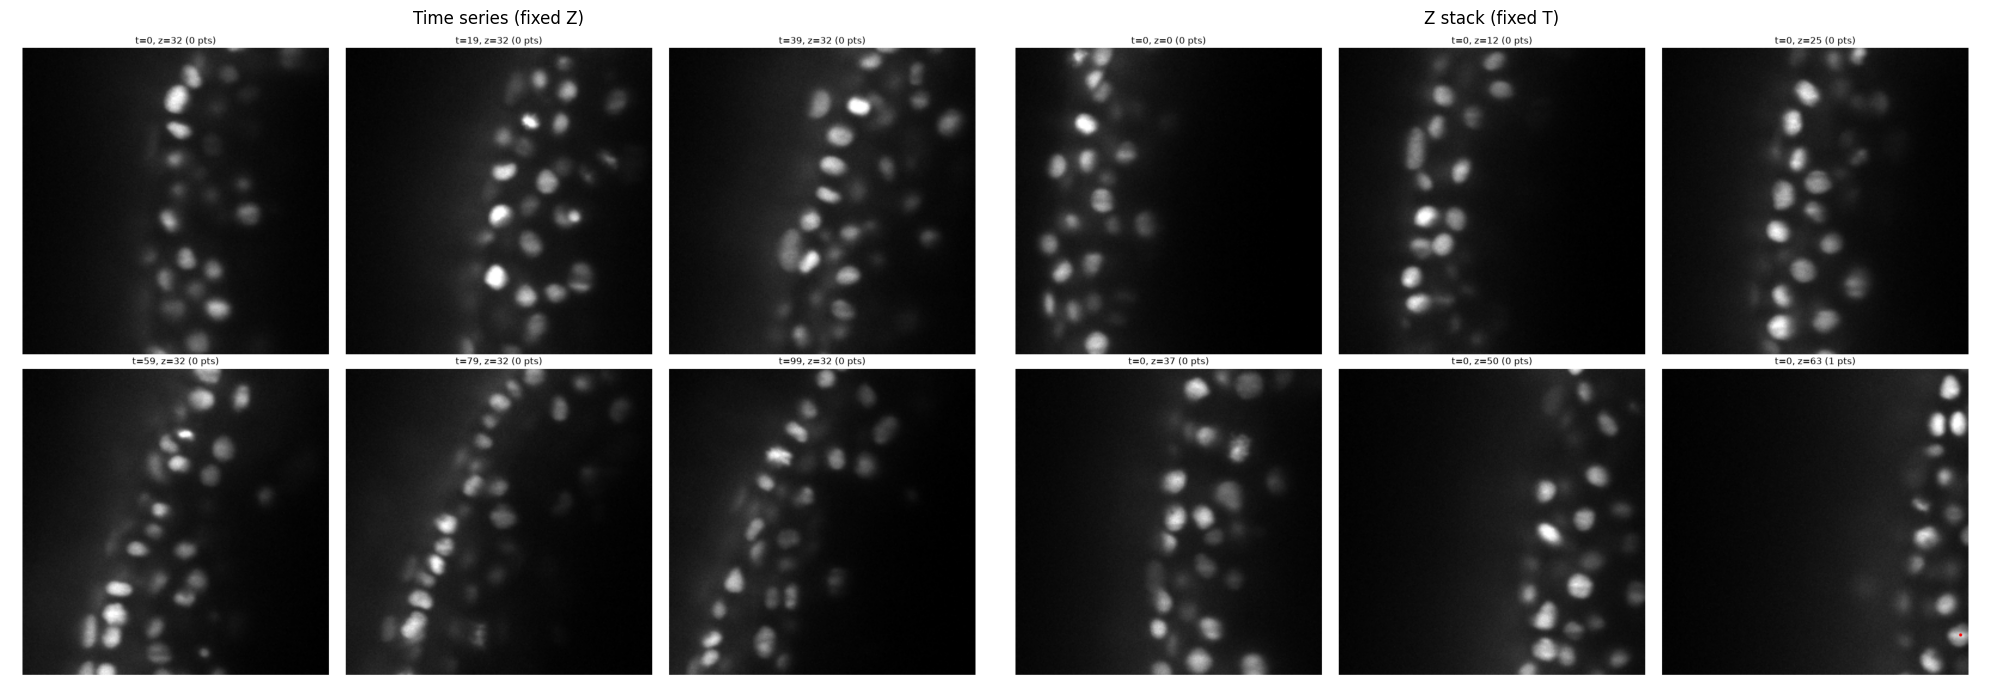

In [24]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

fig, axes = plt.subplots(1, 2, figsize=(20, 10))
axes[0].imshow(mpimg.imread("/kaggle/working/gt_viz/grid.png"))
axes[0].axis("off")
axes[0].set_title("Time series (fixed Z)")

axes[1].imshow(mpimg.imread("/kaggle/working/gt_viz/z_stack.png"))
axes[1].axis("off")
axes[1].set_title("Z stack (fixed T)")

plt.tight_layout()
plt.show()
